# BERT Sentiment Analysis — Main Notebook

- Step 1: Data loading & EDA (quick checks and plots)
- Step 2: Tokenization & DataLoaders (prepare PyTorch inputs)
- Step 3: Train & evaluate models (BERT variants + simple baselines)

In [1]:
# Setup and imports
# Run this cell first. Adds `src/` to path and imports the project helpers.
import sys
sys.path.append('../src')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch

# project modules (py files with the functions we need)
from data_loader import IMDbDataset
from tokenizer import BERTTokenizer, create_dataloaders
from model import BERTSentimentClassifier, BaselineLSTM, BaselineMLP
from trainer import Trainer

np.random.seed(42)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

Using device: cuda


## Configuration

In [2]:
BATCH_SIZE = 16  # default batch size (reduce if GPU memory is low)
MAX_LENGTH = 256  # max tokens per example (256 is a reasonable trade-off)
EPOCHS_BERT = 3  # set small for demo; increase for final runs
EPOCHS_BASELINE = 5
LEARNING_RATE_BERT = 2e-5
LEARNING_RATE_BASELINE = 1e-3
RESULTS_DIR = '../results'  # where training outputs and metrics are saved

# These values are a practical starting point for BERT fine-tuning:
# - Batch size: 16, we decided to not use 32 because of GPU memory constraints 
# - Learning rate: around 2e-5 to 5e-5
# - Epochs: 2 to 4, since BERT can overfit quickly

## 1) Data loading & Exploratory Data Analysis (EDA)

Purpose: load the IMDb dataset, inspect class balance, sample texts and text-length statistics.

Notes:
- The dataset is loaded through `IMDbDataset` from `src/data_loader.py`.
- The plots are shown inline so the reader can follow the data story right away.

In [3]:
# Load dataset using the helper class from src/data_loader.py
imdb = IMDbDataset()
train_data = imdb.train_data
test_data = imdb.test_data

In [4]:
# Basic info and a few sample reviews
imdb.get_info()

IMDb Dataset Info
Number of training examples: 25000
Number of test examples: 25000

Training set class distribution:
Counter({0: 12500, 1: 12500})

Test set class distribution:
Counter({0: 12500, 1: 12500})


In [5]:
imdb.get_sample_texts(n=3)

Sample Reviews (n=3)

Review 1 (Negative):
I rented I AM CURIOUS-YELLOW from my video store because of all the controversy that surrounded it when it was first released in 1967. I also heard that at first it was seized by U.S. customs if it ever tried to enter this country, therefore being a fan of films considered "controversial" I really had to see this for myself.<br /><br />The plot is centered around a young Swedish drama student named Lena who wants to learn everything she can about life. In particular she wants to focus her attent...

Review 2 (Negative):
"I Am Curious: Yellow" is a risible and pretentious steaming pile. It doesn't matter what one's political views are because this film can hardly be taken seriously on any level. As for the claim that frontal male nudity is an automatic NC-17, that isn't true. I've seen R-rated films with male nudity. Granted, they only offer some fleeting views, but where are the R-rated films with gaping vulvas and flapping labia? Nowhere, bec

In [6]:
# Text length analysis
lengths = imdb.analyze_text_length()
print(f'Number of reviews analyzed: {len(lengths)}')

Text Length Analysis
Average words per review: 233.8
Median words per review: 174.0
Min words: 10
Max words: 2470
95th percentile: 598
Number of reviews analyzed: 25000


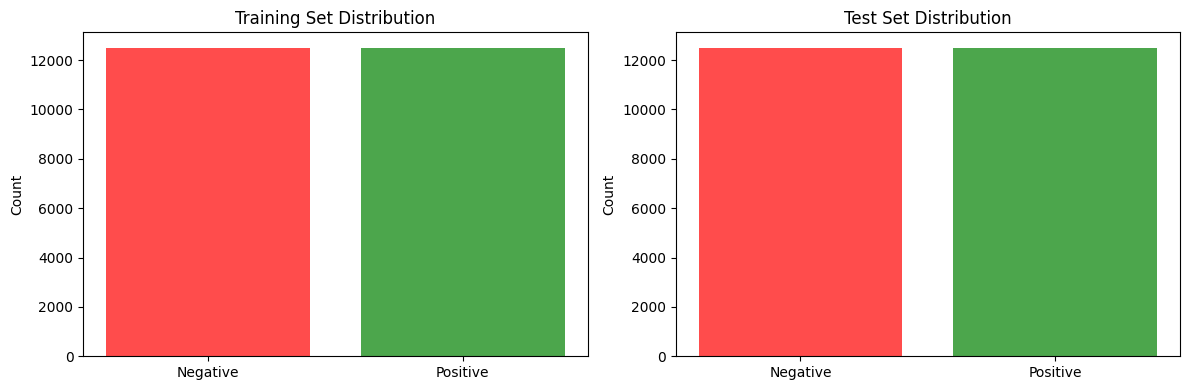

In [7]:
# Plot class distribution inline using the loaded dataset
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

train_labels = train_data['label']
train_counts = [train_labels.count(0), train_labels.count(1)]
axes[0].bar(['Negative', 'Positive'], train_counts, color=['red', 'green'], alpha=0.7)
axes[0].set_title('Training Set Distribution')
axes[0].set_ylabel('Count')

test_labels = test_data['label']
test_counts = [test_labels.count(0), test_labels.count(1)]
axes[1].bar(['Negative', 'Positive'], test_counts, color=['red', 'green'], alpha=0.7)
axes[1].set_title('Test Set Distribution')
axes[1].set_ylabel('Count')

plt.tight_layout()
plt.show()

C:\Users\anton\AppData\Local\Temp\ipykernel_9088\692325909.py:6: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


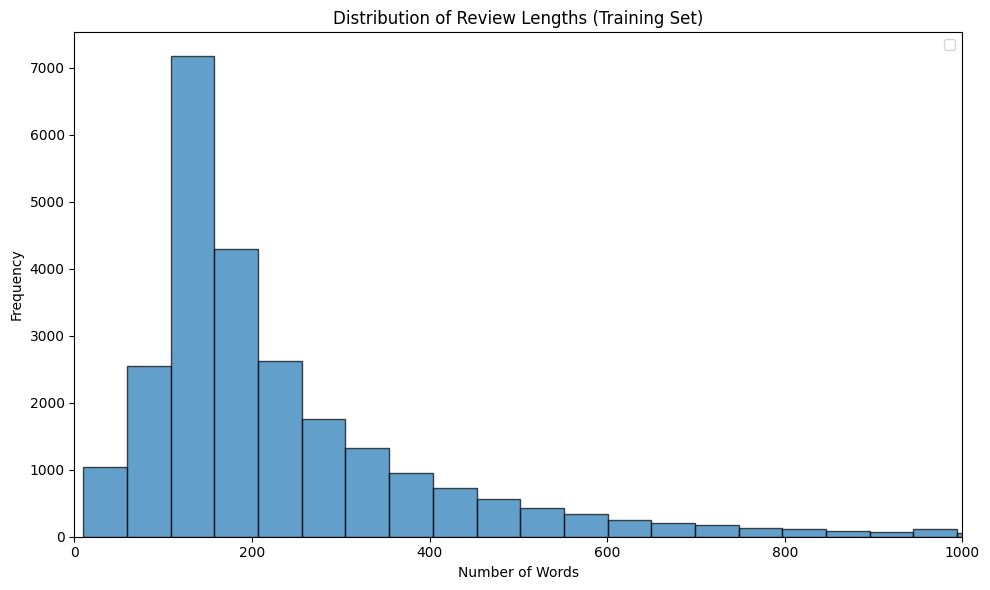

In [8]:
plt.figure(figsize=(10, 6))
plt.hist(lengths, bins=50, alpha=0.7, edgecolor='black')
plt.xlabel('Number of Words')
plt.ylabel('Frequency')
plt.title('Distribution of Review Lengths (Training Set)')
plt.legend()
plt.xlim(0, 1000)
plt.tight_layout()
plt.show()

## 2) Tokenization & DataLoaders

In [9]:
# Tokenizer and DataLoaders
# Build tokenizer and create DataLoaders for train/val/test splits.
# PyTorch DataLoaders ready for the training loop.

tokenizer = BERTTokenizer()
train_size = int(0.9 * len(train_data))
train_texts = train_data['text'][:train_size]
train_labels = train_data['label'][:train_size]
val_texts = train_data['text'][train_size:]
val_labels = train_data['label'][train_size:]
test_texts = test_data['text']
test_labels = test_data['label']

# from tokenizer.py file
train_loader, val_loader, test_loader = create_dataloaders(
    train_texts, train_labels, val_texts, val_labels,
    test_texts, test_labels, tokenizer, batch_size=BATCH_SIZE, max_length=MAX_LENGTH
)

Vocabulary size: 30522
DataLoaders created:
  Training samples: 22500 (1407 batches)
  Validation samples: 2500 (157 batches)
  Test samples: 25000 (1563 batches)
  Batch size: 16
  Max sequence length: 256


## 3) Models & Training

This section trains four models for comparison:
- `BERT Fine-tuned`: full fine-tuning of `bert-base-uncased`.
- `BERT Frozen`: BERT used as a frozen feature extractor with a small head.
- `LSTM` and `MLP` baselines: quick, lightweight baselines for reference.

In [10]:
# Grid Search

# Define hyperparameter grid
learning_rates = [1e-5, 2e-5, 3e-5]
epochs_options = [2, 3, 4]
batch_sizes = [16]

# Store results
grid_results = []

for lr in learning_rates:
    for epochs in epochs_options:
        for batch_size in batch_sizes:
            print(f"Training: LR={lr}, EPOCHS={epochs}, BATCH_SIZE={batch_size}")

            # Recreate dataloaders with new batch size
            train_loader_gs, val_loader_gs, test_loader_gs = create_dataloaders(
                train_texts, train_labels, val_texts, val_labels,
                test_texts, test_labels, tokenizer, batch_size=batch_size, max_length=MAX_LENGTH
            )

            # Create and train model
            model_gs = BERTSentimentClassifier(freeze_bert=False)
            trainer_gs = Trainer(
                model_gs,
                train_loader_gs,
                val_loader_gs,
                test_loader_gs,
                device,
                lr,
                RESULTS_DIR,
                save_artifacts=False
            )

            # Train
            trainer_gs.train(epochs)

            # Evaluate on validation and test sets
            val_loss, val_accuracy, val_f1, _, _ = trainer_gs.evaluate(val_loader_gs)
            test_metrics = trainer_gs.evaluate_test(plot_confusion_matrix=False)

            # Store results
            grid_results.append({
                'learning_rate': lr,
                'epochs': epochs,
                'batch_size': batch_size,
                'val_accuracy': val_accuracy,
                'val_f1': val_f1,
                'test_accuracy': test_metrics['accuracy'],
                'test_f1': test_metrics['f1']
            })

            print(f"Val F1: {val_f1:.4f} | Test F1: {test_metrics['f1']:.4f}\n")

# Convert to DataFrame
grid_results_df = pd.DataFrame(grid_results)

# Show results directly in the notebook
print("Grid Search Results (sorted by validation F1)")
print(grid_results_df.sort_values('val_f1', ascending=False).to_string(index=False))

# Find best configuration
best_idx = grid_results_df['val_f1'].idxmax()
best_config = grid_results_df.loc[best_idx]

print("Best results")
print(f"Learning Rate: {best_config['learning_rate']}")
print(f"Epochs: {best_config['epochs']}")
print(f"Batch Size: {best_config['batch_size']}")
print(f"Validation F1: {best_config['val_f1']:.4f}")
print(f"Test F1: {best_config['test_f1']:.4f}")

Training: LR=1e-05, EPOCHS=2, BATCH_SIZE=16
DataLoaders created:
  Training samples: 22500 (1407 batches)
  Validation samples: 2500 (157 batches)
  Test samples: 25000 (1563 batches)
  Batch size: 16
  Max sequence length: 256

Epoch 1/2


Training: 100%|██████████| 1407/1407 [08:54<00:00,  2.63it/s]


Train Loss: 0.2888, Acc: 0.8836
Val Loss: 0.5201, Acc: 0.8228, F1: 0.9028

Epoch 2/2


Training: 100%|██████████| 1407/1407 [08:57<00:00,  2.62it/s]


Train Loss: 0.1862, Acc: 0.9384
Val Loss: 0.4013, Acc: 0.8700, F1: 0.9305

Test Accuracy: 0.9140
Test F1 Score: 0.9139

Classification Report:
              precision    recall  f1-score   support

    Negative       0.89      0.95      0.92     12500
    Positive       0.94      0.88      0.91     12500

    accuracy                           0.91     25000
   macro avg       0.92      0.91      0.91     25000
weighted avg       0.92      0.91      0.91     25000

Val F1: 0.9305 | Test F1: 0.9139

Training: LR=1e-05, EPOCHS=3, BATCH_SIZE=16
DataLoaders created:
  Training samples: 22500 (1407 batches)
  Validation samples: 2500 (157 batches)
  Test samples: 25000 (1563 batches)
  Batch size: 16
  Max sequence length: 256

Epoch 1/3


...

Train Loss: 0.1727, Acc: 0.9452
Val Loss: 0.5780, Acc: 0.8188, F1: 0.9004

Epoch 3/4


Training: 100%|██████████| 1407/1407 [10:24<00:00,  2.25it/s]


Train Loss: 0.1051, Acc: 0.9718
Val Loss: 0.5042, Acc: 0.8700, F1: 0.9305

Epoch 4/4


Training: 100%|██████████| 1407/1407 [10:20<00:00,  2.27it/s]


Train Loss: 0.0678, Acc: 0.9839
Val Loss: 0.2151, Acc: 0.9424, F1: 0.9703

Test Accuracy: 0.9010
Test F1 Score: 0.9008

Classification Report:
              precision    recall  f1-score   support

    Negative       0.94      0.86      0.90     12500
    Positive       0.87      0.95      0.91     12500

    accuracy                           0.90     25000
   macro avg       0.90      0.90      0.90     25000
weighted avg       0.90      0.90      0.90     25000

Val F1: 0.9703 | Test F1: 0.9008

Grid Search Results (sorted by validation F1)
 learning_rate  epochs  batch_size  val_accuracy   val_f1  test_accuracy  test_f1
       0.00003       4          16        0.9424 0.970346        0.90096 0.900763
       0.00001       3          16        0.9284 0.962871        0.91496 0.914926
       0.00002       3          16        0.9280 0.962656        0.91308 0.913032
       0.00002       4          16        0.9108 0.953318        0.91484 0.914836
       0.00001       4          16      

In [11]:
#best option
EPOCHS_BERT = 4
LEARNING_RATE_BERT = 3e-5

In [12]:
# BERT fine-tuned
# from model.py and trainer.py files
print('Training BERT (fine-tuned)')
model_bert = BERTSentimentClassifier(freeze_bert=False)
trainer_bert = Trainer(model_bert, train_loader, val_loader, test_loader, device, LEARNING_RATE_BERT, f'{RESULTS_DIR}/bert_finetuned')
trainer_bert.train(EPOCHS_BERT)
bert_results = trainer_bert.evaluate_test()

Training BERT (fine-tuned)

Epoch 1/4


Training: 100%|██████████| 1407/1407 [09:22<00:00,  2.50it/s]


Train Loss: 0.2935, Acc: 0.8797
Val Loss: 0.8065, Acc: 0.7472, F1: 0.8553

Epoch 2/4


Training: 100%|██████████| 1407/1407 [09:11<00:00,  2.55it/s]


Train Loss: 0.1711, Acc: 0.9468
Val Loss: 0.3139, Acc: 0.8996, F1: 0.9471

Epoch 3/4


Training: 100%|██████████| 1407/1407 [09:21<00:00,  2.51it/s]


Train Loss: 0.1055, Acc: 0.9719
Val Loss: 0.2187, Acc: 0.9456, F1: 0.9720

Epoch 4/4


Training: 100%|██████████| 1407/1407 [08:49<00:00,  2.66it/s]


Train Loss: 0.0598, Acc: 0.9864
Val Loss: 0.4686, Acc: 0.9032, F1: 0.9491

Test Accuracy: 0.9144
Test F1 Score: 0.9144

Classification Report:
              precision    recall  f1-score   support

    Negative       0.91      0.92      0.91     12500
    Positive       0.92      0.91      0.91     12500

    accuracy                           0.91     25000
   macro avg       0.91      0.91      0.91     25000
weighted avg       0.91      0.91      0.91     25000



In [13]:
# BERT frozen
print('Training BERT (frozen)')
model_frozen = BERTSentimentClassifier(freeze_bert=True)
trainer_frozen = Trainer(model_frozen, train_loader, val_loader, test_loader, device, LEARNING_RATE_BASELINE, f'{RESULTS_DIR}/bert_frozen')
trainer_frozen.train(EPOCHS_BASELINE)
frozen_results = trainer_frozen.evaluate_test()

Training BERT (frozen)

Epoch 1/5


Training: 100%|██████████| 1407/1407 [03:40<00:00,  6.39it/s]


Train Loss: 0.5658, Acc: 0.7047
Val Loss: 0.4774, Acc: 0.7844, F1: 0.8792

Epoch 2/5


Training: 100%|██████████| 1407/1407 [03:39<00:00,  6.42it/s]


Train Loss: 0.5094, Acc: 0.7499
Val Loss: 0.4824, Acc: 0.7684, F1: 0.8690

Epoch 3/5


...

Train Loss: 0.4998, Acc: 0.7588
Val Loss: 0.3402, Acc: 0.8632, F1: 0.9266

Epoch 4/5


Training: 100%|██████████| 1407/1407 [03:44<00:00,  6.27it/s]


Train Loss: 0.4976, Acc: 0.7624
Val Loss: 0.6549, Acc: 0.6472, F1: 0.7858

Epoch 5/5


Training: 100%|██████████| 1407/1407 [03:47<00:00,  6.19it/s]


Train Loss: 0.4913, Acc: 0.7615
Val Loss: 0.5003, Acc: 0.7580, F1: 0.8623

Test Accuracy: 0.8042
Test F1 Score: 0.8036

Classification Report:
              precision    recall  f1-score   support

    Negative       0.77      0.86      0.81     12500
    Positive       0.84      0.75      0.79     12500

    accuracy                           0.80     25000
   macro avg       0.81      0.80      0.80     25000
weighted avg       0.81      0.80      0.80     25000



In [14]:
# LSTM baseline
print('Training LSTM baseline')
model_lstm = BaselineLSTM(vocab_size=tokenizer.vocab_size)
trainer_lstm = Trainer(model_lstm, train_loader, val_loader, test_loader, device, LEARNING_RATE_BASELINE, f'{RESULTS_DIR}/lstm')
trainer_lstm.train(EPOCHS_BASELINE)
lstm_results = trainer_lstm.evaluate_test()

Training LSTM baseline

Epoch 1/5


Training: 100%|██████████| 1407/1407 [02:20<00:00, 10.02it/s]


Train Loss: 0.6190, Acc: 0.6409
Val Loss: 0.4216, Acc: 0.8384, F1: 0.9121

Epoch 2/5


Training: 100%|██████████| 1407/1407 [02:18<00:00, 10.17it/s]


Train Loss: 0.3488, Acc: 0.8592
Val Loss: 0.3562, Acc: 0.8904, F1: 0.9420

Epoch 3/5


...

Train Loss: 0.2186, Acc: 0.9210
Val Loss: 0.6196, Acc: 0.7784, F1: 0.8754

Epoch 4/5


Training: 100%|██████████| 1407/1407 [02:18<00:00, 10.15it/s]


Train Loss: 0.1268, Acc: 0.9592
Val Loss: 0.6885, Acc: 0.7920, F1: 0.8839

Epoch 5/5


Training: 100%|██████████| 1407/1407 [02:16<00:00, 10.32it/s]


Train Loss: 0.0703, Acc: 0.9788
Val Loss: 0.9183, Acc: 0.7760, F1: 0.8739

Test Accuracy: 0.8323
Test F1 Score: 0.8322

Classification Report:
              precision    recall  f1-score   support

    Negative       0.82      0.86      0.84     12500
    Positive       0.85      0.81      0.83     12500

    accuracy                           0.83     25000
   macro avg       0.83      0.83      0.83     25000
weighted avg       0.83      0.83      0.83     25000



In [15]:
# MLP baseline
print('Training MLP baseline')
model_mlp = BaselineMLP(vocab_size=tokenizer.vocab_size)
trainer_mlp = Trainer(model_mlp, train_loader, val_loader, test_loader, device, LEARNING_RATE_BASELINE, f'{RESULTS_DIR}/mlp')
trainer_mlp.train(EPOCHS_BASELINE)
mlp_results = trainer_mlp.evaluate_test()

Training MLP baseline

Epoch 1/5


Training: 100%|██████████| 1407/1407 [01:09<00:00, 20.29it/s]


Train Loss: 0.4202, Acc: 0.8019
Val Loss: 0.4534, Acc: 0.7876, F1: 0.8812

Epoch 2/5


Training: 100%|██████████| 1407/1407 [01:11<00:00, 19.67it/s]


Train Loss: 0.2413, Acc: 0.9054
Val Loss: 0.6270, Acc: 0.7256, F1: 0.8410

Epoch 3/5


...

Train Loss: 0.1684, Acc: 0.9383
Val Loss: 0.7860, Acc: 0.7004, F1: 0.8238

Epoch 4/5


Training: 100%|██████████| 1407/1407 [01:13<00:00, 19.14it/s]


Train Loss: 0.1151, Acc: 0.9604
Val Loss: 0.6658, Acc: 0.7664, F1: 0.8678

Epoch 5/5


Training: 100%|██████████| 1407/1407 [01:14<00:00, 18.86it/s]


Train Loss: 0.0778, Acc: 0.9732
Val Loss: 0.8472, Acc: 0.7616, F1: 0.8647

Test Accuracy: 0.8220
Test F1 Score: 0.8219

Classification Report:
              precision    recall  f1-score   support

    Negative       0.80      0.85      0.83     12500
    Positive       0.84      0.79      0.82     12500

    accuracy                           0.82     25000
   macro avg       0.82      0.82      0.82     25000
weighted avg       0.82      0.82      0.82     25000



## 4) Compare results and save outputs

          Model  Accuracy       F1
BERT Fine-tuned   0.91436 0.914359
    BERT Frozen   0.80416 0.803575
           LSTM   0.83228 0.832170
            MLP   0.82204 0.821893


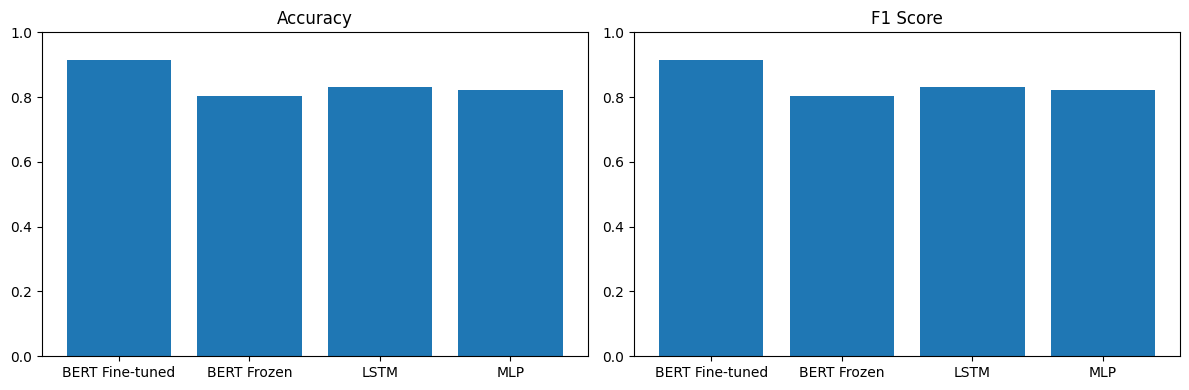

In [16]:
# Collate and save results
results_df = pd.DataFrame({
    'Model': ['BERT Fine-tuned', 'BERT Frozen', 'LSTM', 'MLP'],
    'Accuracy': [bert_results['accuracy'], frozen_results['accuracy'], lstm_results['accuracy'], mlp_results['accuracy']],
    'F1': [bert_results['f1'], frozen_results['f1'], lstm_results['f1'], mlp_results['f1']]
})
print(results_df.to_string(index=False))
results_df.to_csv(f'{RESULTS_DIR}/final_comparison.csv', index=False)

# Show the comparison directly in the notebook
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].bar(results_df['Model'], results_df['Accuracy'])
ax[0].set_title('Accuracy')
ax[0].set_ylim([0, 1])
ax[1].bar(results_df['Model'], results_df['F1'])
ax[1].set_title('F1 Score')
ax[1].set_ylim([0, 1])
plt.tight_layout()
plt.show()


- Consider adding qualitative error analysis and experiments with other pre-trained models (RoBERTa, DistilBERT).